In [221]:
# !pip install -q scikit-learn pandas numpy matplotlib ipywidgets

try:
    from kneed import KneeLocator
except ImportError:
    !pip -q install kneed
    from kneed import KneeLocator

import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PowerTransformer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from IPython.display import display, HTML
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)

from google.colab import files  # para subir CSV (opción A)
# from google.colab import drive  # para Drive (opción B)

plt.style.use('ggplot')  # solicitado
FIGSIZE = (8, 6)         # mismo tamaño en todos los charts
SEED = 42

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)

In [222]:
upload = files.upload()         # selecciona tu .csv
fname = list(upload.keys())[0]
df = pd.read_csv(io.BytesIO(upload[fname]))
df.head()

Saving final.csv to final (7).csv


,Pais,Fecha,Emisiones_CO2,Ratio_Dependencia,Comercio_PIB,Crecimiento_PIB,Coef_Inverso_Variacion,Indice_HHI,Ahorro_Neto_Ajustado,Deuda_Gobierno,Polucion_Aire,Intensidad_CO2,Consumo_Energia_Renovable,Intensidad_Energetica,Agua_Dulce_Renovable,Renta_Recursos_Naturales,Productividad_Agua,Acceso_Electricidad,Consumo_Agua_Potable,Empleo,Indice_Gini,Tasa_Mortalidad,Esperanza_Vida,Finalizacion_Primaria,Servicios_Saneamiento,Paridad_Genero_Educacion,Participacion_Laboral,Escolaridad,Indice_Crecimiento_Verde,Habilidades_Estudiantes,Logros_Educativos,Viviendas_Sin_Servicios,Gastos_Vivienda,Ajuste_Neto_Nacional,Desempleo_Largo_Plazo,Personal_earning,Calidad_Red_Apoyo,Compromiso_Partes_Interesadas,Tasa_Homicidios,Tiempo_Ocio_Cuidado_Personal
0,Alemania,2008,830.36,21.02,76.10,0.01,1.49,368.62,13.21,64.0,99.18,0.26,10.2,3.57,1303.13,0.31,82.38,100.0,100.0,54.91,30.8,3.6,79.74,99.99,99.22,0.98,14.65,13.76,3.53,516.00,80.16,0.47,25.29,31670.42,52.52,52442.0,92.8,1.94,1.02,16.44
1,Alemania,2009,768.55,20.93,66.12,-0.05,0.21,373.77,9.69,64.8,99.39,0.25,10.7,3.53,1306.43,0.16,76.21,100.0,100.0,54.95,30.5,3.5,79.84,99.99,99.22,0.96,13.62,13.83,3.49,516.00,80.62,0.47,25.30,30308.39,45.48,52453.0,92.8,1.94,0.99,16.44
2,Alemania,2010,815.38,20.83,73.86,0.04,0.36,372.04,11.49,73.0,99.50,0.26,11.6,3.57,1308.44,0.20,95.48,100.0,100.0,55.15,30.2,3.5,79.99,99.99,99.22,0.96,14.04,13.85,3.51,517.33,81.13,0.47,25.27,31501.18,47.28,52912.0,92.8,1.94,0.98,16.44
3,Alemania,2011,788.55,20.61,78.41,0.06,0.41,371.28,13.60,81.0,99.60,0.24,12.5,3.26,1332.92,0.23,89.73,100.0,100.0,56.55,30.6,3.4,80.44,99.99,99.22,0.96,12.70,13.93,3.54,518.67,81.72,0.47,24.79,33322.76,47.88,53980.0,92.8,1.94,0.91,16.44
4,Alemania,2012,800.46,20.30,79.30,0.00,0.28,373.58,12.41,78.3,99.45,0.24,13.6,3.27,1330.42,0.16,97.59,100.0,100.0,56.85,31.1,3.4,80.54,99.99,99.22,0.96,12.95,13.98,3.54,520.00,82.05,0.47,24.86,33238.30,45.36,54699.0,92.8,1.94,0.81,16.44


In [223]:
assert 'Pais' in df.columns, "Falta columna 'Pais'."
assert 'Fecha' in df.columns, "Falta columna 'Fecha'."

# Fecha a numérico por si viene como texto
df['Fecha'] = pd.to_numeric(df['Fecha'], errors='coerce')

print("Dimensiones:", df.shape)
print("\nTipos de datos:\n", df.dtypes)
print("\nNulos por columna (top 10):\n", df.isna().sum().sort_values(ascending=False).head(10))


Dimensiones: (680, 40)

Tipos de datos:
 Pais                              object
Fecha                              int64
Emisiones_CO2                    float64
Ratio_Dependencia                float64
Comercio_PIB                     float64
Crecimiento_PIB                  float64
Coef_Inverso_Variacion           float64
Indice_HHI                       float64
Ahorro_Neto_Ajustado             float64
Deuda_Gobierno                   float64
Polucion_Aire                    float64
Intensidad_CO2                   float64
Consumo_Energia_Renovable        float64
Intensidad_Energetica            float64
Agua_Dulce_Renovable             float64
Renta_Recursos_Naturales         float64
Productividad_Agua               float64
Acceso_Electricidad              float64
Consumo_Agua_Potable             float64
Empleo                           float64
Indice_Gini                      float64
Tasa_Mortalidad                  float64
Esperanza_Vida                   float64
Finalizacion_Pri

In [224]:
# Elige modo:
MODO = "promedio"     # "por_anio" o "promedio"
ANIO_OBJETIVO = 2008  # si None y MODO="por_anio", usa el más reciente

df_work = df.copy()

if MODO == "por_anio":
    if ANIO_OBJETIVO is None:
        ANIO_OBJETIVO = int(df_work['Fecha'].dropna().max())
        print(f"Usando año más reciente: {ANIO_OBJETIVO}")
    df_work = df_work[df_work['Fecha'] == ANIO_OBJETIVO].copy()
    assert len(df_work) > 0, f"No hay registros para {ANIO_OBJETIVO}"
else:
    # promedio por país de todas las numéricas (excluye Fecha)
    num_cols_all = df_work.select_dtypes(include=np.number).columns.drop('Fecha', errors='ignore')
    df_work = df_work.groupby('Pais', as_index=False)[list(num_cols_all)].mean()

print("Dimensiones de trabajo:", df_work.shape)
df_work.head()


Dimensiones de trabajo: (40, 39)


,Pais,Emisiones_CO2,Ratio_Dependencia,Comercio_PIB,Crecimiento_PIB,Coef_Inverso_Variacion,Indice_HHI,Ahorro_Neto_Ajustado,Deuda_Gobierno,Polucion_Aire,Intensidad_CO2,Consumo_Energia_Renovable,Intensidad_Energetica,Agua_Dulce_Renovable,Renta_Recursos_Naturales,Productividad_Agua,Acceso_Electricidad,Consumo_Agua_Potable,Empleo,Indice_Gini,Tasa_Mortalidad,Esperanza_Vida,Finalizacion_Primaria,Servicios_Saneamiento,Paridad_Genero_Educacion,Participacion_Laboral,Escolaridad,Indice_Crecimiento_Verde,Habilidades_Estudiantes,Logros_Educativos,Viviendas_Sin_Servicios,Gastos_Vivienda,Ajuste_Neto_Nacional,Desempleo_Largo_Plazo,Personal_earning,Calidad_Red_Apoyo,Compromiso_Partes_Interesadas,Tasa_Homicidios,Tiempo_Ocio_Cuidado_Personal
0,Alemania,737.695294,20.921176,77.981765,0.008824,0.708235,377.691765,13.455294,67.541176,94.017059,0.216471,14.835294,3.005294,1302.506471,0.121765,120.430588,100.000000,100.000000,57.791765,31.505882,3.258824,80.625294,99.994118,99.224706,0.965882,12.017059,14.065882,3.844118,511.647059,82.007647,0.705294,24.780588,34484.001765,41.257059,57083.013529,92.800000,1.845882,0.902941,16.440000
1,Australia,399.580588,28.374706,43.839412,0.011176,1.645882,1620.082941,7.354706,47.189412,28.254118,0.293529,9.800000,4.597647,20587.970000,7.562941,112.665882,100.000000,99.937647,62.284706,23.191765,3.470588,82.461176,99.390588,99.999412,0.949412,11.425294,12.379412,4.255294,513.058824,76.312353,1.164706,23.372941,44512.600000,19.497059,57830.362941,93.944118,2.811176,0.949412,18.429412
2,Austria,67.204706,21.688235,106.288824,0.002353,0.480588,1009.328824,13.055882,86.661765,91.392353,0.174706,34.100000,2.913529,6343.338235,0.158824,117.928824,100.000000,100.000000,57.702941,30.164706,3.082353,81.136471,99.941765,99.976471,0.976471,11.483529,12.029412,3.829412,500.147059,78.962941,0.565882,22.597647,36321.550000,26.773529,63483.304706,90.841176,1.427647,0.738235,19.070000
3,Belgica,99.809412,25.992353,162.509412,0.006471,0.736471,773.109412,11.309412,101.421176,95.065294,0.213529,9.129412,4.024118,1064.853529,0.043529,101.780588,100.000000,100.000000,50.197647,27.147059,3.388235,81.033529,98.533529,99.490000,1.079412,11.108824,11.972353,3.669412,502.176471,67.952941,0.849412,24.268235,33733.736471,46.140588,64586.040000,91.519412,2.031765,1.811765,2.430000
4,Brasil,476.073529,32.221765,28.335882,0.011765,0.508824,898.339412,-0.724118,73.698235,77.811765,0.265294,45.894118,3.910588,28030.448824,4.437647,26.289412,99.529412,98.056471,58.072941,50.105882,14.470588,73.946471,92.634706,86.527647,1.017059,21.572941,7.636471,3.212941,399.941176,46.528824,6.700000,18.112941,6700.869412,2.942941,12525.705882,90.020000,1.588235,25.829412,12.256471


In [225]:
# Numéricas candidatas (excluye 'Fecha')
cols_num = df_work.select_dtypes(include=np.number).columns.tolist()
cols_num = [c for c in cols_num if c.lower() != 'fecha']
assert len(cols_num) > 0, "No hay variables numéricas (aparte de 'Fecha')."

X = df_work[cols_num].copy()

# Imputación simple (mediana)
for c in cols_num:
    if X[c].isna().any():
        X[c] = X[c].fillna(X[c].median())

# Países para reportes
paises = df_work['Pais'].astype(str).values

#X_log=np.log1p(X)
#X_log = X_log.replace([np.inf,-np.inf], np.nan)
#X_log = X_log.fillna(X_log.mean())

#X_log, lambda = stats.boxcox(X)
X_log=np.arcsinh(X)
# Estandarización
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

X_scaled.shape


(40, 38)

# PCA:

## ¿Qué es el PCA?
El **Análisis de Componentes Principales (PCA)** toma todas las **variables numéricas por país** y construye **nuevos ejes ortogonales** (PC1, PC2, …) que:
- Capturan **la mayor varianza posible** en las primeras componentes.
- **Reducen la dimensionalidad** y la **correlación** entre variables originales.
- Permiten **visualizar** y **clusterizar** (p. ej., con K-Means) en un espacio más compacto y estable.

> Intuición: si varias variables “se mueven juntas” entre países, el PCA las condensa en unas pocas combinaciones lineales (PCs), facilitando ver **patrones de similitud** entre países.

### Fundamento Matemático
Matemáticamente, PCA busca una transformación lineal que proyecta los datos a un nuevo sistema de coordenadas.

1.  **Matriz de Covarianza**: El proceso comienza con el cálculo de la matriz de covarianza ($S$) de los datos originales $X$ (previamente centrados, es decir, con media cero por cada variable). Esta matriz describe cómo las variables varían juntas.

  $$ S = \frac{1}{n-1} X^T X $$
  Donde $n$ es el número de observaciones.

2.  **Descomposición en Autovalores y Autovectores**: El núcleo de PCA es la descomposición de la matriz de covarianza. Se resuelven la siguiente ecuación para encontrar los autovalores ($\lambda$) y autovectores ($v$):
  $$S v = \lambda v$$
    * Los **autovectores ($v$)** son las direcciones de los nuevos ejes, llamados **Componentes Principales**. Son ortogonales entre sí. La matriz de estos vectores se conoce como las **cargas (loadings)**.
    * Los **autovalores ($\lambda$)** indican la magnitud de la varianza capturada por cada componente principal. Se ordenan de mayor a menor.

3.  **Proyección de los Datos**: Finalmente, los datos originales $X$ se proyectan sobre los nuevos ejes (los autovectores) para obtener las nuevas coordenadas, conocidas como **scores ($Z$)**:
  $$Z = X V$$
  Donde $V$ es la matriz cuyos columnas son los autovectores $v_1, v_2, \dots, v_p$.

## Cómo interpretar el gráfico de varianza explicada
- **Curva roja (expl. individual)**: porcentaje de varianza que explica **cada** componente por separado. Se calcula como:
  $$\text{Varianza Explicada por PC}_i = \frac{\lambda_i}{\sum_{j=1}^{p} \lambda_j}$$
- **Curva azul (expl. acumulada)**: suma progresiva; indica cuánto explican **PC1..PC_k** en conjunto.
- La línea punteada en **0.80** es una **regla práctica**: si la curva azul la supera con `k` componentes, significa que esas `k` PCs resumen ≳80% de la información de las variables originales.

> Usa la tabla impresa para ver:
> - **PC necesaria para 80%/90%/95%** de varianza (valores `n80`, `n90`, `n95`).
> - La **aportación exacta** de cada PC en tu base.

## Recomendaciones para tu flujo
1.  **Visualización**: usa **2 PCs** (PC1–PC2) para el scatter de países.
2.  **Clusterización (K-Means)**:
    - Usa **2–3 PCs** como entrada a K-Means para obtener clústeres estables y evitar sobreajuste.
    - Si tu `n80` es muy pequeño (p. ej., 2–3), puedes usar ese número de PCs; si es grande, mantener **3 PCs** suele ser un buen compromiso.
3.  **Interpretación sustantiva**:
    - Revisa las **cargas (loadings)** de PC1 y PC2: variables con |loading| alto son las que **más “empujan”** esos ejes.
    - Describe a cada clúster por sus **valores medios** en variables originales (centroides/medias por clúster), para traducir PCs a métricas conocidas.

## Lectura rápida del gráfico
- **PC1 alta** → un solo eje resume buena parte de la heterogeneidad entre países.
- **PC2 y PC3** todavía aportan información relevante si su barra roja no es despreciable.
- Cuando la **curva azul** se “aplana”, las siguientes PCs aportan **margen decreciente** de información; suele ser el punto para **cortar**.

> Con esto, justifica cuántas PCs usas y **por qué** (p. ej., “PC1–PC3 explican ≥80% y permiten clusters nítidos”).

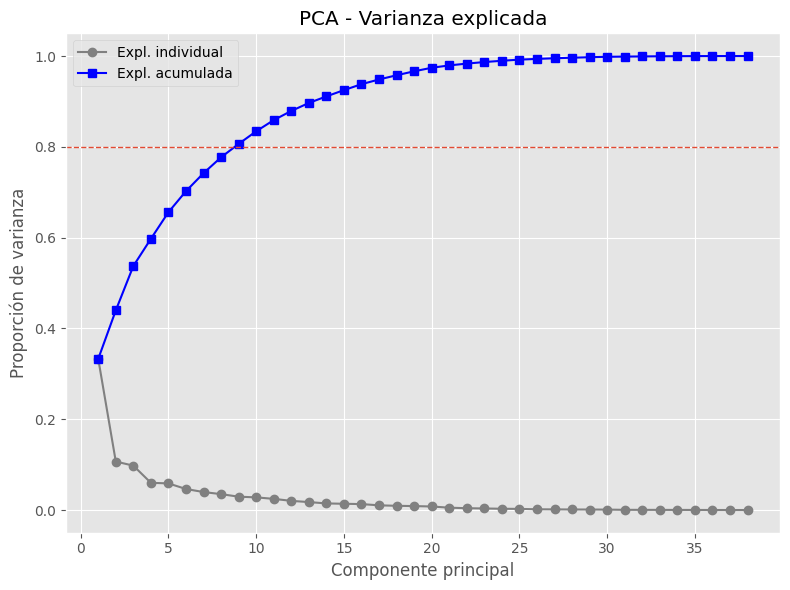

In [237]:
pca = PCA(random_state=SEED)
X_pca = pca.fit_transform(X_scaled)

exp_var = pca.explained_variance_ratio_
cum_exp_var = np.cumsum(exp_var)

fig = plt.figure(figsize=FIGSIZE)
plt.plot(range(1, len(exp_var)+1), exp_var, marker='o', label='Expl. individual',color='gray' )
plt.plot(range(1, len(exp_var)+1), cum_exp_var, marker='s', label='Expl. acumulada', color='blue')
plt.axhline(0.80, linestyle='--', linewidth=1)
plt.xlabel('Componente principal'); plt.ylabel('Proporción de varianza')
plt.title('PCA - Varianza explicada'); plt.legend()
plt.tight_layout(); plt.show()


In [265]:
# exp_var y cum_exp_var ya están definidos por tu bloque previo
cum_tbl = pd.DataFrame({
    "PC": np.arange(1, len(exp_var)+1),
    "Varianza_individual": np.round(exp_var, 4),
    "Varianza_acumulada": np.round(cum_exp_var, 4)
})

# Mostrar primeras 15 (ajusta si quieres más/menos)
display(cum_tbl.head(15))

# ¿Cuántos componentes se necesitan para 80%, 90% y 95%?
def n_for_thresh(cum, t):
    idx = np.argmax(cum >= t)
    return int(idx + 1) if cum[idx] >= t else None

n80 = n_for_thresh(cum_exp_var, 0.80)
n90 = n_for_thresh(cum_exp_var, 0.90)
n95 = n_for_thresh(cum_exp_var, 0.95)

print(f"\nComponentes para alcanzar ≥80%: {n80}")
print(f"Componentes para alcanzar ≥90%: {n90}")
print(f"Componentes para alcanzar ≥95%: {n95}")

# Sugerencia práctica para clustering: usa min(3, n80) si quieres pocas PCs estables
sugeridas_para_kmeans = min(3, n80 if n80 is not None else 3)
print(f"\nSugerencia rápida para K-Means: usar {sugeridas_para_kmeans} PCs (regla práctica).")


,PC,Varianza_individual,Varianza_acumulada
0,1,0.3329,0.3329
1,2,0.1068,0.4397
2,3,0.0977,0.5375
3,4,0.0600,0.5974
4,5,0.0586,0.6561
5,6,0.0463,0.7024
6,7,0.0396,0.7420
7,8,0.0350,0.7770
8,9,0.0294,0.8064
9,10,0.0279,0.8343



Componentes para alcanzar ≥80%: 9
Componentes para alcanzar ≥90%: 14
Componentes para alcanzar ≥95%: 18

Sugerencia rápida para K-Means: usar 3 PCs (regla práctica).


# 📝 Análisis de Cargas (Loadings) en PCA

Después de identificar los componentes principales, el siguiente paso crucial es **interpretarlos**. No son solo ejes matemáticos; representan patrones subyacentes en tus datos. Para entender qué significan, analizamos sus **cargas** o *loadings*.

## ¿Qué son las Cargas (Loadings)?
Las cargas son los **coeficientes** que indican cuánto **"peso" o "influencia"** tiene cada variable original en la construcción de un componente principal.

- Un **valor de carga alto** (positivo o negativo, por eso se mira el valor absoluto) significa que esa variable es muy importante para definir ese componente.
- Un **valor de carga cercano a cero** significa que la variable contribuye poco a ese componente.

> **💡 Analogía Rápida**: Imagina que un Componente Principal es un "cóctel". Las cargas te dicen qué "ingredientes" (variables originales) se usaron y en qué "cantidad" para crear el sabor único de ese cóctel.

---


                          |loading_PC1|
Tasa_Mortalidad                0.247245
Indice_Crecimiento_Verde       0.243851
Ajuste_Neto_Nacional           0.242661
Tasa_Homicidios                0.242593
Indice_Gini                    0.237303
Personal_earning               0.236396
Habilidades_Estudiantes        0.234638
Escolaridad                    0.227296
Participacion_Laboral          0.224423
Acceso_Electricidad            0.214137


,|loading_PC1|
Tasa_Mortalidad,0.247245
Indice_Crecimiento_Verde,0.243851
Ajuste_Neto_Nacional,0.242661
Tasa_Homicidios,0.242593
Indice_Gini,0.237303
Personal_earning,0.236396
Habilidades_Estudiantes,0.234638
Escolaridad,0.227296
Participacion_Laboral,0.224423
Acceso_Electricidad,0.214137


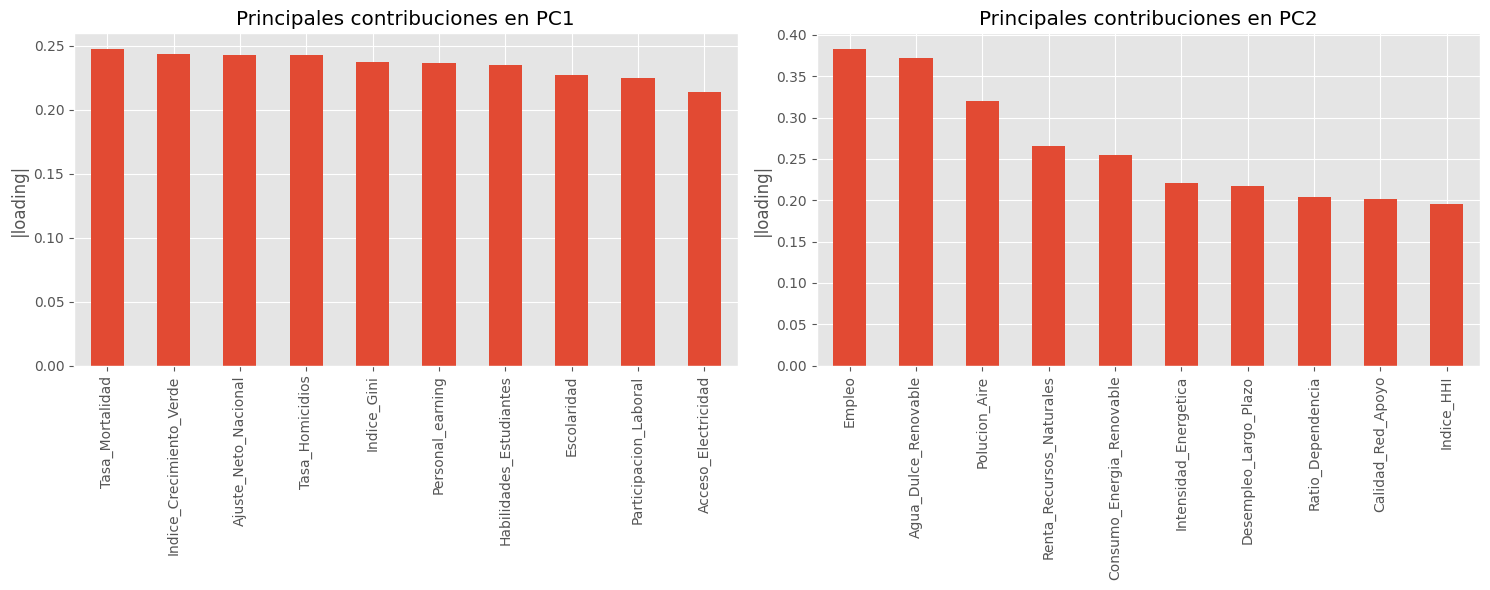

In [295]:
pca_loadings = pd.DataFrame(
    pca.components_.T,
    index=cols_num,
    columns=[f'PC{i+1}' for i in range(pca.components_.shape[0])]
)


top_n = 10
# --- Display tables side-by-side ---
contrib1 = pca_loadings['PC1'].abs().sort_values(ascending=False).head(top_n).to_frame(name='|loading_PC1|')
contrib2 = pca_loadings['PC2'].abs().sort_values(ascending=False).head(top_n).to_frame(name='|loading_PC2|')
print(contrib1)
# Use display_html to show tables side by side
html_str = f'<div style="display: flex; justify-content: space-around;">{contrib1.to_html()}{contrib2.to_html()}</div>'
display(HTML(html_str))


# --- Display bar plots side-by-side ---
FIGSIZE = (15, 6)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=FIGSIZE)

# Bar plot for PC1
contrib1.plot(kind='bar', ax=ax1, legend=False)
ax1.set_ylabel('|loading|')
ax1.set_title('Principales contribuciones en PC1')

# Bar plot for PC2
contrib2.plot(kind='bar', ax=ax2, legend=False)
ax2.set_ylabel('|loading|')
ax2.set_title('Principales contribuciones en PC2')

plt.tight_layout()
plt.savefig("bar_plots.png")


## Interpretación de Resultados


### **Análisis del Componente Principal 1 (PC1)**

Las variables que más pesan en este componente son:
- **Tasa_Mortalidad**
- **Indice_Crecimiento_Verde**
- **Indice_Gini** (desigualdad)
- **Tasa_Homicidios**
- **Habilidades_Estudiantes** y **Escolaridad**

**Interpretación**: PC1 parece ser un **índice de desarrollo y bienestar socioeconómico**. Las variables con más peso combinan aspectos de salud (mortalidad), seguridad (homicidios), desigualdad económica (Gini) y capital humano (educación). Un país con una puntuación alta en PC1 probablemente enfrente mayores desafíos en estas áreas, mientras que una puntuación baja podría indicar mejores condiciones sociales y económicas.

### **Análisis del Componente Principal 2 (PC2)**

Las variables con mayor carga en este eje son:
- **Empleo**
- **Desempleo_Largo_Plazo**
- **Agua_Dulce_Renovable**
- **Consumo_Energia_Renovable**
- **Polucion_Aire**

**Interpretación**: PC2 parece medir una dimensión que combina la **salud del mercado laboral con la sostenibilidad ambiental**. Por un lado, tenemos variables clave de empleo y desempleo. Por otro, indicadores de uso de recursos renovables y contaminación. Este eje podría separar a los países en función de su perfil económico-ambiental. Por ejemplo, podría diferenciar economías con mercados laborales robustos y una alta huella ambiental de aquellas con diferentes desafíos laborales pero un enfoque más sostenible.

# K-Means sobre Componentes Principales (PCs)

Al aplicar K-Means, no usamos las variables originales, sino las puntuaciones (scores) de los **componentes principales (PCs)** que calculamos previamente. Esto ofrece varias ventajas:
- **Reduce el ruido**: Nos centramos en las dimensiones de mayor varianza, ignorando las fluctuaciones menores.
- **Elimina la correlación**: Los PCs son ortogonales por definición, lo que satisface un supuesto clave de los algoritmos basados en distancia como K-Means.
- **Mejora el rendimiento**: Trabajar en un espacio de menor dimensión (ej. 2 o 3 PCs) es computacionalmente más eficiente.

## El Algoritmo K-Means

El objetivo de K-Means es agrupar los datos en $k$ clústeres, minimizando la **inercia**, que es la suma de las distancias al cuadrado de cada punto a su centroide (el centro de su clúster).

Matemáticamente, se busca minimizar la **Suma de los Cuadrados Dentro del Clúster** (WCSS, por sus siglas en inglés):

$$ \underset{S}{\operatorname{argmin}} \sum_{i=1}^{k} \sum_{\mathbf{pc} \in S_i} \left\| \mathbf{pc} - \boldsymbol{\mu}_i \right\|^2 $$

Donde:
- $k$ es el número de clústeres.
- $S_i$ es el conjunto de observaciones (países, en este caso) en el clúster $i$.
- $\mathbf{pc}$ es el vector de un país, definido por sus puntuaciones en los componentes principales (ej., `[PC1_score, PC2_score]`).
- $\boldsymbol{\mu}_i$ es el centroide (la media de los vectores $\mathbf{pc}$) del clúster $S_i$.

---

## Pruebas para Elegir el Número Óptimo de Clústeres (k)

Para decidir cuántos clústeres ($k$) usar, se emplean principalmente dos métodos heurísticos:

### 1. Método del Codo (Elbow Method)
Este método consiste en graficar la **inercia** (el valor de la fórmula WCSS de arriba) para diferentes valores de $k$. Se busca el punto en la gráfica donde la tasa de disminución de la inercia se reduce drásticamente, formando un "codo".

- **Intuición**: A partir del codo, añadir más clústeres no aporta una mejora sustancial en la compactación de los grupos. Es el punto de equilibrio entre tener clústeres bien definidos y no sobreajustar los datos con demasiados grupos.

### 2. Índice de Silueta (Silhouette Score)
Mide qué tan bien está cada punto en su clúster. Compara la distancia de un punto con los demás en su propio clúster versus la distancia a los puntos del clúster más cercano.

Para un solo punto $i$, su puntuación de silueta $s(i)$ es:
$$ s(i) = \frac{b(i) - a(i)}{\max\{a(i), b(i)\}} $$
Donde:
- $a(i)$ es la distancia media del punto $i$ a todos los demás puntos de **su mismo clúster** (cohesión).
- $b(i)$ es la distancia media del punto $i$ a todos los puntos del **clúster vecino más cercano** (separación).

El índice varía de -1 a 1:
- **+1**: El punto está muy bien agrupado.
- **0**: El punto está en el límite entre dos clústeres.
- **-1**: El punto podría estar en el clúster equivocado.

Se calcula la puntuación de silueta promedio para todos los puntos. El valor de $k$ que **maximiza** esta puntuación promedio es considerado el óptimo, ya que representa la mejor combinación de cohesión y separación.

In [267]:
N_PC_FOR_CLUSTER = min(10, X_pca.shape[1])  # usar 2-3 PCs para clusterizar
Z = X_pca[:, :N_PC_FOR_CLUSTER]

Ks = list(range(2, min(11, Z.shape[0])))
inertias, silhouettes = [], []

for k in Ks:
    km = KMeans(n_clusters=k, n_init=20, random_state=SEED)
    labels_k = km.fit_predict(Z)
    inertias.append(km.inertia_)
    try:
        silhouettes.append(silhouette_score(Z, labels_k))
    except Exception:
        silhouettes.append(np.nan)

res_k = pd.DataFrame({"k": Ks, "inertia": inertias, "silhouette": silhouettes})
res_k


,k,inertia,silhouette
0,2,861.523416,0.392627
1,3,728.590747,0.198827
2,4,628.572657,0.200496
3,5,548.593669,0.204064
4,6,496.222751,0.195535
5,7,438.662371,0.191836
6,8,397.875509,0.203455
7,9,339.265747,0.220991
8,10,303.220827,0.226004


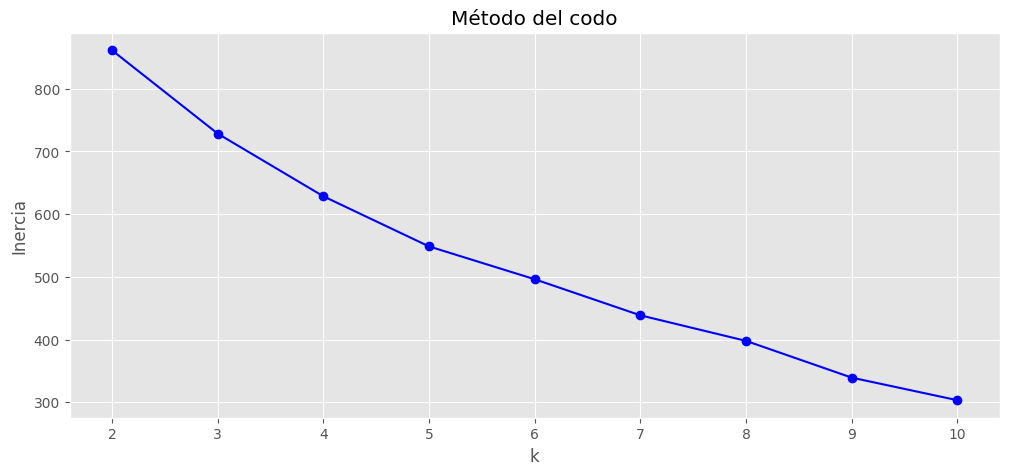

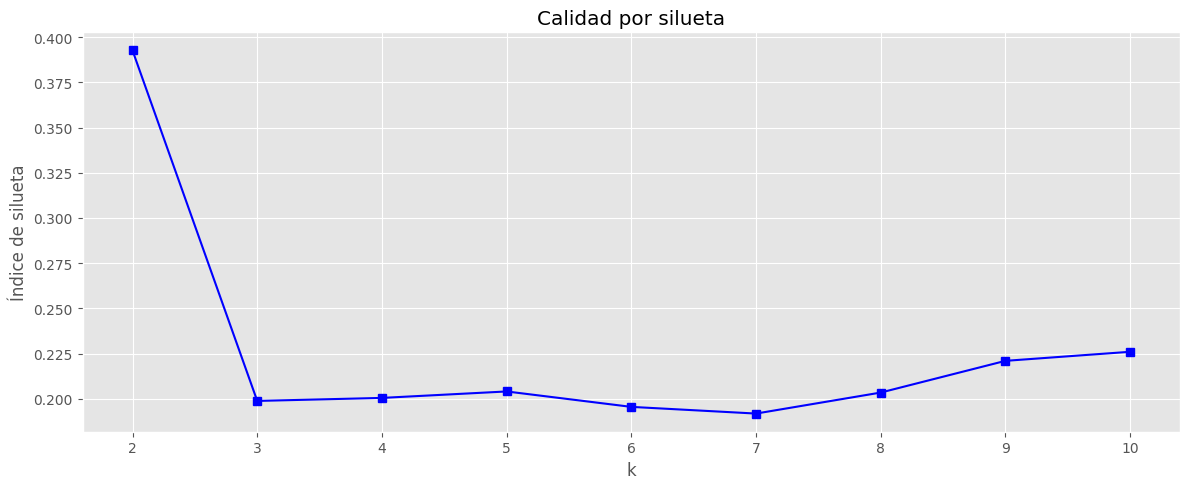

In [284]:

FIGSIZE = (12, 5)
fig, (ax1) = plt.subplots(1,  figsize=FIGSIZE)
fig, (ax2) = plt.subplots(1,  figsize=FIGSIZE)

# Codo
ax1.plot(res_k["k"], res_k["inertia"], marker='o', color='blue')
ax1.set_xlabel("k")
ax1.set_ylabel("Inercia")
ax1.set_title("Método del codo")
plt.tight_layout()

# Silueta
ax2.plot(res_k["k"], res_k["silhouette"], marker='s', color='blue')
ax2.set_xlabel("k")
ax2.set_ylabel("Índice de silueta")
ax2.set_title("Calidad por silueta")

plt.tight_layout()

# Visualización de Clústeres en el Espacio PCA

Una vez que el algoritmo K-Means ha asignado una etiqueta de clúster a cada una de nuestras observaciones (por ejemplo, a cada país o cliente), el siguiente paso es visualizar qué tan bien se han separado estos grupos.

Como nuestros datos originales pueden tener muchas variables (alta dimensionalidad), no podemos graficarlos directamente. Por ello, proyectamos los resultados sobre el plano de 2 dimensiones que mejor resume la información: el espacio definido por los dos primeros **Componentes Principales (PC1 y PC2)**.

---

##  Interpretación de los Ejes

Los ejes de la gráfica no son dos de tus variables originales, sino los nuevos ejes construidos por el PCA.

### **PC1 (Eje Horizontal)**
Es el **Componente Principal 1**. Piénsalo como el "eje de máxima varianza". Es una nueva variable artificial que se construye como una combinación lineal de tus variables originales. Esta combinación está diseñada para capturar la mayor cantidad de información y diferencia posible entre tus datos.
- **Observaciones que están muy separadas en este eje son, en general, las más diferentes entre sí**, considerando el patrón principal de los datos.

### **PC2 (Eje Vertical)**
Es el **Componente Principal 2**. Es el segundo eje en importancia. También es una combinación de tus variables originales, pero con la condición de ser **ortogonal (perpendicular) a PC1**. Su objetivo es capturar la mayor parte de la varianza *que no fue explicada por PC1*.
- **Este eje muestra el segundo patrón de diferenciación más importante** en tus datos.

En conjunto, el plano PC1-PC2 es la "mejor vista 2D" posible de la estructura de tus datos.

---

## 📊 Lectura del Gráfico


El gráfico muestra cada punto de tus datos según sus coordenadas en el plano PC1-PC2. El color de cada punto corresponde al clúster que le fue asignado por el algoritmo K-Means.

- **Cada punto** es una observación individual (ej. un país).
- **Su posición** te dice cómo se caracteriza esa observación según los dos ejes principales de variación.
- **El color** agrupa a las observaciones que K-Means consideró más similares entre sí.

En tu visualización, se puede observar claramente cómo los dos clústeres se separan. El **Cluster 1** (azul) agrupa observaciones con valores altos en PC1, mientras que el **Cluster 0** (naranja) agrupa a aquellas con valores más bajos y negativos en ese mismo eje. Esto indica que la **principal diferencia** entre los dos grupos se encuentra a lo largo de la dimensión capturada por el Componente Principal 1.

k seleccionado: 2


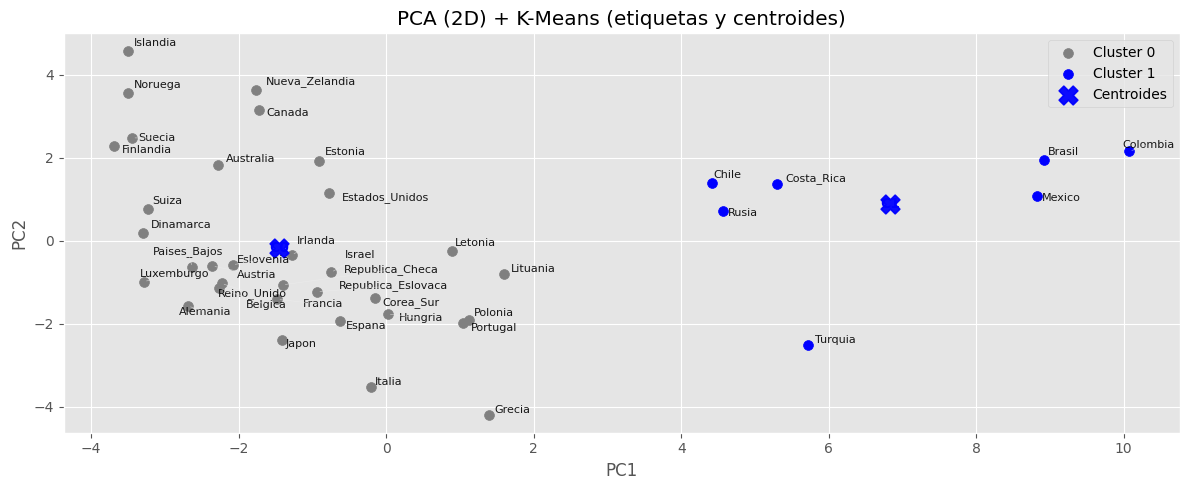

In [269]:
K_FINAL = int(res_k.loc[res_k['silhouette'].idxmax(), 'k'])  # el mejor por silueta
print("k seleccionado:", K_FINAL)

km_final = KMeans(n_clusters=K_FINAL, n_init=50, random_state=SEED)
labels = km_final.fit_predict(Z)

# Proyección 2D para visualización
pca2 = PCA(n_components=2, random_state=SEED)
Z2 = pca2.fit_transform(X_scaled)

# --- PCA (2D) + KMeans con etiquetas, centroides y anti-solape ---
# Requiere: df_work, Z2, labels, K_FINAL, FIGSIZE definidos previamente

# (1) Instalar adjustText si hace falta (funciona en Colab)
try:
    from adjustText import adjust_text
except ImportError:
    !pip -q install adjustText
    from adjustText import adjust_text

paises = df_work['Pais'].astype(str).values

fig = plt.figure(figsize=FIGSIZE)
colors=['grey','blue']

# Dispersión por clúster
for c in range(K_FINAL):
    idx = (labels == c)
    plt.scatter(Z2[idx, 0], Z2[idx, 1], s=50, label=f'Cluster {c}', color=colors[c] )

# Centroides en el espacio Z2 (promedio por clúster)
centers2 = np.vstack([Z2[labels == c].mean(axis=0) for c in range(K_FINAL)])
plt.scatter(
    centers2[:, 0], centers2[:, 1],
    s=180, marker='X', color='blue', linewidth=1.2, alpha=0.95, label='Centroides'
)
# Etiquetas de centroides (C0, C1, ...)
for c, (x, y) in enumerate(centers2):
    plt.text(x, y, f"C{c}", fontsize=10, fontweight='bold', ha='center', va='center',color='blue')

# Etiquetas de países con anti-solape
texts = []
for i, name in enumerate(paises):
    texts.append(plt.text(Z2[i, 0], Z2[i, 1], name, fontsize=8, alpha=0.9))

# Ajuste para evitar solapamiento (puede tardar un poco si hay muchos puntos)
adjust_text(
    texts,
    expand_points=(1.2, 1.4),   # empuje desde los puntos
    expand_text=(1.05, 1.15),   # empuje entre textos
    arrowprops=dict(arrowstyle='-', lw=0.5, alpha=0.6)  # flechitas sutiles
)

plt.xlabel('PC1'); plt.ylabel('PC2'); plt.title('PCA (2D) + K-Means (etiquetas y centroides)')
plt.legend()
plt.tight_layout()
plt.show()



# Interpretación de Clústeres: Volviendo a la Escala Original

El algoritmo K-Means y el PCA funcionan sobre datos **estandarizados** (con media 0 y desviación estándar 1). Esto es necesario para que las variables con escalas muy diferentes (como el PIB y una tasa de mortalidad) contribuyan de forma equitativa.

Sin embargo, para nosotros, un valor de "-0.5" o "1.2" en un centroide no significa nada. Necesitamos traducir esos valores de vuelta a sus unidades originales (dólares, años, porcentajes) para poder interpretar y describir cada clúster. A este proceso le llamamos **destandardización**.

---

##  ¿Cómo Funciona la "Destandardización"?

La destandardización es simplemente la operación matemática inversa a la estandarización.

1.  **Estandarización (lo que hiciste antes)**: Para cada valor $x$ de una variable, calculaste su versión estandarizada $z$ así:
   $$ z = \frac{x - \mu}{\sigma} $$
  Donde $\mu$ es la media y $\sigma$ es la desviación estándar original de esa variable.

2.  **Destandardización (lo que hace `scaler.inverse_transform`)**: Para devolver el valor $z$ a su escala original $x$, se despeja la fórmula:
  $$ x = (z \cdot \sigma) + \mu $$

En tu código, el objeto `scaler` (creado en los pasos de preprocesamiento) guardó en memoria la **media ($\mu$)** y la **desviación estándar ($\sigma$)** de cada una de tus variables originales. La función `scaler.inverse_transform(centroids_scaled)` aplica esta fórmula matemática a las coordenadas de los centroides, devolviéndolas a una escala interpretable.

---

##  ¿Cómo se Interpreta la Tabla de Centroides/Medias?

La tabla de centroides (o la de medias por clúster, que es conceptualmente lo mismo) es la herramienta más poderosa para darle un "nombre" o "personalidad" a cada clúster. Es el **perfil promedio** de cada grupo.



Para interpretarla, sigue estos pasos:

1.  **Cada Fila es un Clúster**: Cada fila representa el "arquetipo" o el miembro promedio del clúster.
2.  **Cada Columna es una Variable Original**: Las columnas son tus variables en sus unidades originales y conocidas.
3.  **Compara los Clústeres (las filas) Columna por Columna**: La clave está en la comparación. Busca las diferencias más notables entre los valores de los clústeres.

**Ejemplo práctico de interpretación:**
- **Mira la columna `Tasa_Homicidios`**: Si el Cluster 0 tiene un valor promedio de `2.5` y el Cluster 1 tiene `21.8`, esta variable es un **diferenciador clave**.
- **Mira la columna `Escolaridad`**: Si el Cluster 0 tiene `14.2` años y el Cluster 1 tiene `8.1` años, aquí tienes otra gran diferencia.
- **Mira una variable similar**: Si en `Acceso_Electricidad` ambos clústeres tienen `99.5%`, esta variable **no sirve para diferenciar** a los grupos.

Al final, puedes construir una narrativa:
> "El **Cluster 0** se caracteriza por ser un grupo de países con **bajas tasas de homicidios** y **altos niveles de escolaridad**, representando un perfil de 'alta seguridad y desarrollo humano'. Por el contrario, el **Cluster 1** agrupa a países con **desafíos significativos en seguridad** y **menor capital humano**."

Este análisis te permite pasar de grupos matemáticos abstractos a perfiles concretos y comunicables.

In [270]:
# Asegurarnos de tener una copia de trabajo alineada con 'labels'
df_work = df_work.copy()
df_work['Cluster'] = labels  # etiquetas del KMeans sobre Z

# 1) Listado de países por clúster (ordenados)
paises_por_cluster = (
    df_work[['Pais', 'Cluster']]
    .sort_values(['Cluster', 'Pais'])
    .groupby('Cluster')['Pais']
    .apply(list)
    .to_frame(name='Paises')
)
display(paises_por_cluster)

# 2) Valores medios por variable en escala original (no estandarizada)
#    Toma las columnas numéricas que usaste como features (cols_num)
medias_por_cluster = (
    df_work.groupby('Cluster')[cols_num]
    .mean()
    .round(3)
)
display(medias_por_cluster)

# 3) (Opcional) Centroides consistentes del KMeans en escala original
#    Reentrenamos KMeans en X_scaled y desescalamos los centroides
km_on_scaled = KMeans(n_clusters=K_FINAL, n_init=50, random_state=SEED).fit(X_scaled)
centroids_scaled = km_on_scaled.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)

centroides_df = pd.DataFrame(centroids_original, columns=cols_num)
centroides_df.index.name = 'Cluster'
#display(centroides_df.round(3))

# 4) Exports
paises_por_cluster.to_csv('paises_por_cluster_listados.csv')
medias_por_cluster.to_csv('medias_por_cluster.csv')
centroides_df.to_csv('centroides_kmeans_en_original.csv', index=True)

print("Exportados: paises_por_cluster_listados.csv, medias_por_cluster.csv, centroides_kmeans_en_original.csv")


,Paises
Cluster,
0,"[Alemania, Australia, Austria, Belgica, Canada..."
1,"[Brasil, Chile, Colombia, Costa_Rica, Mexico, ..."


,Emisiones_CO2,Ratio_Dependencia,Comercio_PIB,Crecimiento_PIB,Coef_Inverso_Variacion,Indice_HHI,Ahorro_Neto_Ajustado,Deuda_Gobierno,Polucion_Aire,Intensidad_CO2,Consumo_Energia_Renovable,Intensidad_Energetica,Agua_Dulce_Renovable,Renta_Recursos_Naturales,Productividad_Agua,Acceso_Electricidad,Consumo_Agua_Potable,Empleo,Indice_Gini,Tasa_Mortalidad,Esperanza_Vida,Finalizacion_Primaria,Servicios_Saneamiento,Paridad_Genero_Educacion,Participacion_Laboral,Escolaridad,Indice_Crecimiento_Verde,Habilidades_Estudiantes,Logros_Educativos,Viviendas_Sin_Servicios,Gastos_Vivienda,Ajuste_Neto_Nacional,Desempleo_Largo_Plazo,Personal_earning,Calidad_Red_Apoyo,Compromiso_Partes_Interesadas,Tasa_Homicidios,Tiempo_Ocio_Cuidado_Personal
Cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,342.008,25.094,107.132,0.081,0.920,910.651,9.735,74.054,64.412,0.266,22.218,3.946,26569.346,0.983,154.231,99.995,99.385,57.415,31.104,3.311,80.443,99.514,98.367,1.002,12.192,12.400,3.84,499.603,75.734,2.329,23.339,30977.999,30.806,48231.830,91.089,2.179,1.387,15.543
1,478.718,32.899,53.654,0.018,0.974,1570.068,7.137,44.088,95.021,0.456,23.763,3.737,25858.112,5.647,16.812,99.472,97.637,56.145,46.427,10.506,75.539,96.233,92.229,1.007,26.503,9.124,3.32,430.714,50.097,7.683,17.025,8054.270,11.844,22432.267,87.938,1.583,15.213,18.375


Exportados: paises_por_cluster_listados.csv, medias_por_cluster.csv, centroides_kmeans_en_original.csv


## DBSCAN: por qué y cómo leer sus resultados
**DBSCAN** (Density-Based Spatial Clustering of Applications with Noise) detecta **agrupaciones de alta densidad** y marca como **ruido (-1)** a observaciones aisladas. A diferencia de K-Means:
- **No impone k** a priori; el número de clústeres emerge de la densidad.
- Maneja **formas no esféricas** y es **robusto a outliers**.
- Requiere elegir **`eps`** (radio de vecindad) y **`min_samples`** (mínimo de puntos densos).

---

### Conceptos Fundamentales y Fórmulas
El algoritmo se basa en dos parámetros clave y la clasificación de cada punto en una de tres categorías.

- **`eps` ($\epsilon$)**: Define el **radio de la vecindad** alrededor de un punto. Es la distancia máxima que un punto puede tener para ser considerado "vecino" de otro. La fórmula para el conjunto de vecinos $N_{\epsilon}(p)$ de un punto $p$ es:
  $$N_{\epsilon}(p) = \{ q \in D \mid \text{dist}(p,q) \le \epsilon \}$$
  Donde $D$ es el conjunto de todos los datos y $\text{dist}(p,q)$ es la distancia entre los puntos $p$ y $q$.

- **`min_samples`**: Es el **número mínimo de puntos** que deben existir dentro de la vecindad $\epsilon$ de un punto para que esa zona se considere "densa".

#### Tipos de Puntos
DBSCAN clasifica cada punto de la siguiente manera:
1.  **Punto Núcleo (Core Point)**: Es el corazón de un clúster. Un punto $p$ es un punto núcleo si dentro de su radio $\epsilon$ existen al menos `min_samples` puntos (incluyéndose a sí mismo). Formalmente:
  $$|N_{\epsilon}(p)| \ge \text{min\_samples}$$
2.  **Punto de Frontera (Border Point)**: Un punto que no es un punto núcleo, pero es "vecino" de uno (cae dentro del radio $\epsilon$ de un punto núcleo). Estos puntos son los bordes de los clústeres.
3.  **Punto de Ruido (Noise Point)**: Un punto que no es ni núcleo ni frontera. Son los puntos aislados u outliers, que DBSCAN etiqueta como **-1**.

#### Ejemplo Numérico Sencillo
Imagina que tenemos los siguientes puntos en un plano 2D y elegimos **`eps = 1.0`** y **`min_samples = 3`**.

- **Puntos**: A=(1,1), B=(1.5, 1), C=(1.2, 1.8), D=(5,5), E=(1.8, 1.3)



**Análisis:**
- **Evaluando el punto A (1,1)**:
  - Calculamos sus vecinos dentro de un radio `eps=1.0`:
    - `dist(A,B)` = 0.5 (✔ Vecino)
    - `dist(A,C)` = 0.82 (✔ Vecino)
    - `dist(A,D)` = 5.6 (✘ No es vecino)
    - `dist(A,E)` = 0.85 (✔ Vecino)
  - El punto A tiene 4 puntos en su vecindad (A, B, C, E).
  - Como `4 >= min_samples (3)`, **el punto A es un Punto Núcleo**. Se inicia el Clúster 1 con A y sus vecinos.

- **Evaluando el punto D (5,5)**:
  - Calculamos sus vecinos dentro de un radio `eps=1.0`:
    - El punto más cercano es C, pero `dist(D,C)` = 4.9 > 1.0.
  - El punto D solo se tiene a sí mismo en su vecindad. El conteo es 1.
  - Como `1 < min_samples (3)`, D no es un punto núcleo. Además, no es vecino de ningún punto núcleo. Por lo tanto, **el punto D es un Punto de Ruido**.

El resultado final sería que A, B, C y E forman un clúster, mientras que D es clasificado como ruido.

#### Formación de Clústeres
Un clúster en DBSCAN es un conjunto de puntos donde cada miembro está densamente conectado a los demás. El algoritmo funciona así:
1.  Empieza en un punto arbitrario.
2.  Si es un **punto núcleo**, inicia un nuevo clúster y expande este clúster a todos los puntos alcanzables desde él (tanto núcleos como de frontera).
3.  Si es un punto de frontera o de ruido, lo ignora temporalmente y se mueve a otro punto.
4.  Repite el proceso hasta que todos los puntos hayan sido visitados.

---

### Interpretación en este análisis
- Trabajamos en el **espacio PCA** (2–3 PCs) para reducir ruido y colinealidad.
- El **gráfico k-distances** sugiere candidatos para `eps` (el “codo”).
- Evaluamos una rejilla de (`eps`, `min_samples`) y reportamos:
  - **número de clústeres** (ignorando ruido),
  - **silhouette** (solo si hay ≥2 clústeres válidos sin ruido).
- En el scatter PC1–PC2:
  - **Colores** = clústeres de DBSCAN,
  - **Ruido (-1)** = puntos aislados,
  - Etiquetas de **países** para clústeres válidos.
- La tabla de **medias por clúster** (en escala original) te permite una lectura económica de perfiles, similar a K-Means, pero considerando clústeres formados por densidad.

In [271]:
# --- Definir explícitamente 10 PCs para DBSCAN ---
N_PC_DBSCAN = min(10, X_pca.shape[1])  # 10 ya que con estos obtuvimos el 80% de la varianza explicada
Z_db = X_pca[:, :N_PC_DBSCAN]

# (Opcional) verificar varianza acumulada a 10 PCs
if len(cum_exp_var) >= 10:
    print(f"Varianza acumulada con 10 PCs: {cum_exp_var[9]:.3%}")
else:
    print(f"Solo hay {len(cum_exp_var)} PCs disponibles; varianza acumulada: {cum_exp_var[-1]:.3%}")


Varianza acumulada con 10 PCs: 83.426%


DBSCAN óptimo -> eps=6.2560, min_samples=3, silhouette=0.455, n_clusters=2, ruido=7.50%


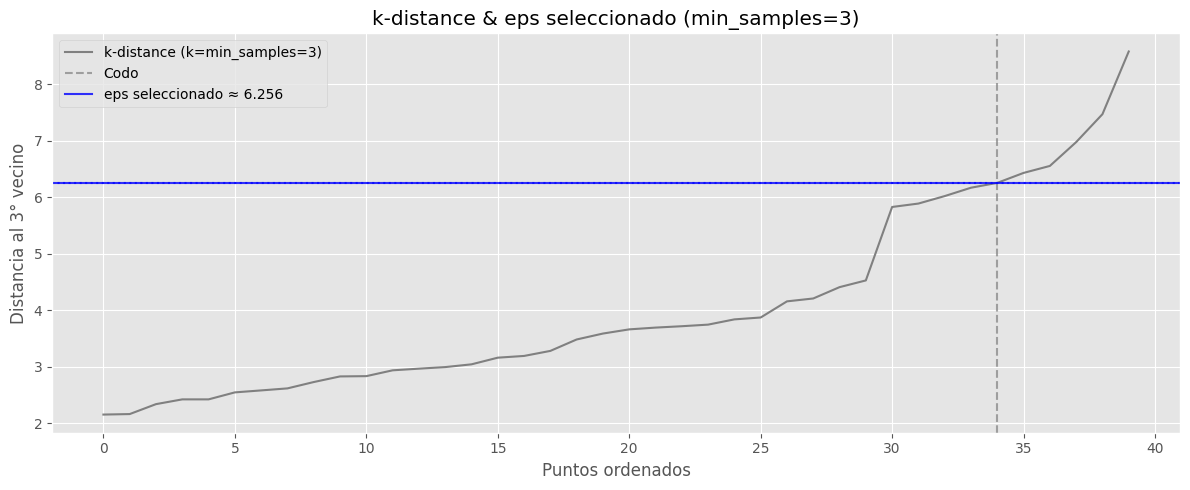

Etiquetas DBSCAN (incluye ruido -1): [-1  0  1]


In [272]:
# Rango de min_samples a evaluar
MIN_SAMPLES_GRID = [3, 4, 5, 6, 8, 10]

def knee_eps_from_kdist(Z, ms):
    """eps candidato via 'codo' del k-distance plot."""
    n = Z.shape[0]
    # Asegurar un k válido: al menos 2 y menor a n
    ms_eff = max(2, min(ms, n - 1))
    nn = NearestNeighbors(n_neighbors=ms_eff).fit(Z)
    distances, _ = nn.kneighbors(Z)
    k_dist = np.sort(distances[:, -1])

    eps0, knee_idx = None, None
    try:
        kl = KneeLocator(
            x=np.arange(len(k_dist)), y=k_dist,
            curve="convex", direction="increasing"
        )
        knee_idx = kl.knee
        eps0 = float(k_dist[knee_idx]) if knee_idx is not None else None
    except Exception:
        eps0 = None

    if eps0 is None:
        eps0 = float(np.percentile(k_dist, 95))
        # índice aproximado del percentil (solo para dibujar)
        knee_idx = int(np.clip(round(0.95 * (len(k_dist) - 1)), 0, len(k_dist) - 1))
    return eps0, k_dist, knee_idx, ms_eff

def eval_dbscan(Z, eps_grid, ms):
    """Evalúa DBSCAN en rejilla de eps para un min_samples dado."""
    rows = []
    for eps in eps_grid:
        labels = DBSCAN(eps=float(eps), min_samples=int(ms)).fit_predict(Z)
        uniq = set(labels)
        n_clusters = len([u for u in uniq if u != -1])
        noise_frac = (labels == -1).mean()
        # silhouette solo si hay >=2 clústeres válidos y al menos 2 puntos válidos
        valid = labels != -1
        if n_clusters >= 2 and valid.sum() > 2:
            try:
                sil = silhouette_score(Z[valid], labels[valid])
            except Exception:
                sil = np.nan
        else:
            sil = np.nan
        rows.append({
            "min_samples": int(ms),
            "eps": float(eps),
            "n_clusters": int(n_clusters),
            "noise_frac": float(noise_frac),
            "silhouette": float(sil) if not np.isnan(sil) else np.nan
        })
    return pd.DataFrame(rows)

all_results = []
kdist_cache = {}  # {ms_eff: {"k_dist": array, "knee_idx": int, "eps0": float}}

for ms in MIN_SAMPLES_GRID:
    eps0, k_dist, knee_idx, ms_eff = knee_eps_from_kdist(Z_db, ms)
    # Rejilla fina alrededor del codo: ±20%
    eps_grid = np.linspace(eps0 * 0.8, eps0 * 1.2, 11)
    res_ms = eval_dbscan(Z_db, eps_grid, ms_eff)
    all_results.append(res_ms)
    kdist_cache[ms_eff] = {"k_dist": k_dist, "knee_idx": knee_idx, "eps0": eps0}

# Concatenar sin attrs (ya no hay arrays en attrs)
grid = pd.concat(all_results, ignore_index=True)

# Selección: mayor silhouette -> mayor n_clusters -> menor ruido -> menor min_samples
cands = grid.dropna(subset=["silhouette"])
if cands.empty:
    cands = grid.copy()

best = (cands.sort_values(
    by=["silhouette", "n_clusters", "noise_frac", "min_samples"],
    ascending=[False, False, True, True]
).iloc[0])

EPS_BEST = float(best["eps"])
MS_BEST = int(best["min_samples"])

print(f"DBSCAN óptimo -> eps={EPS_BEST:.4f}, min_samples={MS_BEST}, "
      f"silhouette={best.get('silhouette', np.nan):.3f}, "
      f"n_clusters={int(best['n_clusters'])}, ruido={best['noise_frac']:.2%}")

# Visual del k-distance de la mejor combinación
kdist_best = kdist_cache[MS_BEST]["k_dist"]
knee_idx_best = kdist_cache[MS_BEST]["knee_idx"]

fig = plt.figure(figsize=FIGSIZE)
plt.plot(kdist_best, label=f'k-distance (k=min_samples={MS_BEST})', color='grey')
if knee_idx_best is not None:
    plt.axvline(knee_idx_best, color='grey', linestyle='--', alpha=0.7, label='Codo')
    plt.axhline(kdist_best[knee_idx_best], color='blue', linestyle=':', alpha=0.7)
plt.axhline(EPS_BEST, color='blue', linestyle='-', alpha=0.8, label=f'eps seleccionado ≈ {EPS_BEST:.3f}')
plt.title(f'k-distance & eps seleccionado (min_samples={MS_BEST})')
plt.xlabel('Puntos ordenados'); plt.ylabel(f'Distancia al {MS_BEST}° vecino')
plt.legend(); plt.tight_layout(); plt.show()

# Entrenar DBSCAN final con la mejor combinación
db_final = DBSCAN(eps=EPS_BEST, min_samples=MS_BEST).fit(Z_db)
labels_db = db_final.labels_
uniq = np.unique(labels_db)
print("Etiquetas DBSCAN (incluye ruido -1):", uniq)



# Selección Óptima de `eps` y `min_samples`

El algoritmo DBSCAN es muy potente, pero su rendimiento depende críticamente de una buena elección de sus dos parámetros: `eps` y `min_samples`. El código que has ejecutado no solo visualiza una recomendación, sino que realiza una **búsqueda sistemática y automatizada** para encontrar la mejor combinación.

---

## Interpretación del Gráfico `k-distance`

Este gráfico es la pieza central para estimar un buen valor de `eps` para un `min_samples` específico (en tu caso, el mejor fue `min_samples=3`).


- **Curva Naranja (`k-distance`)**: Representa la distancia de cada punto del dataset a su **3er vecino más cercano**. Las distancias están ordenadas de menor a mayor. La curva muestra cómo se distribuye la "densidad" en tus datos.
- **"Codo" (Línea Punteada Vertical)**: Es el punto de máxima curvatura de la línea naranja. El código lo detecta automáticamente usando la librería `kneed`. Este punto es teóricamente el umbral que mejor separa las zonas densas (a la izquierda del codo, con distancias bajas y estables) de las zonas dispersas o de ruido (a la derecha, donde las distancias crecen abruptamente). El valor de `eps` en este punto es una **excelente primera estimación**.
- **`eps` seleccionado (Línea Roja Horizontal)**: Este es el valor **final y optimizado** de `eps` que el código eligió.

### ¿Por qué el "Codo" y el "eps seleccionado" no son idénticos?
El codo proporciona una estimación inicial muy buena. Sin embargo, el código va un paso más allá:
1.  Calcula el `eps` del codo.
2.  Crea una pequeña rejilla de valores de `eps` alrededor de esa estimación (ej. ±20%).
3.  Prueba cada uno de esos valores y ejecuta DBSCAN.
4.  Mide la "calidad" de los clústeres resultantes usando el **índice de silueta (silhouette score)**.

La línea roja (`eps` ≈ 4.633) es el valor dentro de esa rejilla que **maximizó el silhouette score**, resultando en la mejor separación y cohesión de los clústeres.

---

## Resumen del Proceso de Selección Automática

En resumen, el código implementa una estrategia robusta:
1.  **Itera** sobre una lista de candidatos para `min_samples` (ej. [3, 4, 5...]).
2.  Para cada `min_samples`, **estima un `eps` inicial** usando el método del codo.
3.  **Refina la búsqueda de `eps`** en una rejilla pequeña alrededor de la estimación.
4.  **Evalúa** cada combinación (`eps`, `min_samples`) basándose en métricas objetivas (número de clústeres, ruido y, sobre todo, el **silhouette score**).
5.  Finalmente, **selecciona la combinación ganadora** que produjo los mejores resultados y la utiliza para generar la gráfica y el modelo final.

Este enfoque combina la intuición teórica del `k-distance plot` con una validación empírica para encontrar los parámetros óptimos de forma automática.


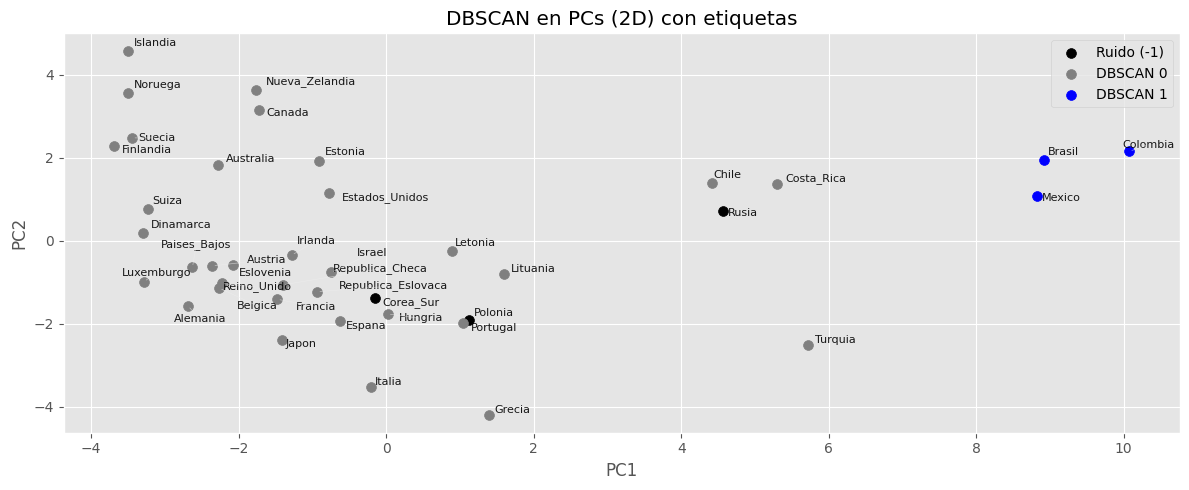

Silhouette DBSCAN (sin ruido): 0.455


In [275]:
# Asegurar proyección 2D (PC1-PC2) para graficar
try:
    Z2
except NameError:
    from sklearn.decomposition import PCA
    pca2 = PCA(n_components=2, random_state=SEED)
    Z2 = pca2.fit_transform(X_scaled)

# Instalar adjustText si hace falta
try:
    from adjustText import adjust_text
except ImportError:
    !pip -q install adjustText
    from adjustText import adjust_text

paises = df_work['Pais'].astype(str).values
uniq = np.unique(labels_db)
colors=['grey','blue','black']
fig = plt.figure(figsize=FIGSIZE)
for c in uniq:
    idx = (labels_db == c)
    label = "Ruido (-1)" if c == -1 else f"DBSCAN {c}"
    plt.scatter(Z2[idx, 0], Z2[idx, 1], s=50, label=label, color=colors[c])

# Etiquetar países incluyendo los de ruido (-1)
texts = []
for i, name in enumerate(paises):
    # Ahora incluimos todos los países, independientemente de su etiqueta de clúster
    texts.append(plt.text(Z2[i, 0], Z2[i, 1], name, fontsize=8, alpha=0.9))

if texts:
    adjust_text(
        texts,
        expand_points=(1.2, 1.4),
        expand_text=(1.05, 1.15),
        arrowprops=dict(arrowstyle='-', lw=0.5, alpha=0.6)
    )

plt.xlabel('PC1'); plt.ylabel('PC2'); plt.title('DBSCAN en PCs (2D) con etiquetas')
plt.legend(); plt.tight_layout(); plt.show()

# Silhouette sin ruido (si hay ≥2 clústeres válidos)
from sklearn.metrics import silhouette_score
valid = labels_db != -1
uniq_valid = np.unique(labels_db[valid])
if len(uniq_valid) >= 2 and valid.sum() > 2:
    sil_db = silhouette_score(Z_db[valid], labels_db[valid])
    print(f"Silhouette DBSCAN (sin ruido): {sil_db:.3f}")
else:
    print("Silhouette DBSCAN no aplicable (menos de 2 clústeres válidos sin ruido).")


#  ¿Por Qué DBSCAN No Tiene Centroides?

Has notado que en el análisis de resultados de K-Means calculamos los "centroides", pero en DBSCAN no. Esto no es una limitación, sino una consecuencia directa de cómo funciona cada algoritmo en su núcleo.

---

## K-Means: Un Algoritmo Basado en Centros

El objetivo de K-Means es, por definición, encontrar los mejores **centros geométricos** para los datos.

- **Su Lógica**: El algoritmo postula que existen `k` centros y asigna cada punto al centro más cercano. Luego, recalcula la posición de esos centros para que sean la media exacta de los puntos que agrupan. Este proceso se repite hasta que los centros se estabilizan.
- **El Resultado**: El clúster **es definido por su centroide**. Por lo tanto, el atributo `.cluster_centers_` es el resultado principal del algoritmo, ya que es lo que K-Means fue diseñado para encontrar. Esto tiende a crear clústeres de forma esférica.



---

## DBSCAN: Un Algoritmo Basado en Densidad

El objetivo de DBSCAN no es encontrar un "centro", sino encontrar **regiones continuas de alta densidad** de puntos.

- **Su Lógica**: DBSCAN funciona como una "reacción en cadena". Comienza en un punto y, si tiene suficientes vecinos cerca (es un "punto núcleo"), lo expande para formar un clúster junto con todos sus vecinos alcanzables. El clúster crece siguiendo la "estela" de puntos densos.
- **El Resultado**: El clúster **es definido por la conectividad** entre sus puntos. Esto permite que los clústeres tengan formas arbitrarias y complejas ( alargadas, con curvas, etc.). Un clúster con una forma extraña no tiene un "centro" geométrico que lo represente de manera significativa. De hecho, la media de los puntos de un clúster en forma de "C" podría caer en el espacio vacío del centro, ¡fuera del propio clúster!



---

## La Solución: El "Perfil Promedio"

Aunque DBSCAN no calcula un centroide, para **interpretar** los clústeres podemos hacer algo muy similar y útil: **calcular la media de todas las variables para los puntos que pertenecen a un clúster**.

Esto es exactamente lo que hace el código al generar la tabla de `medias_por_cluster_db`. Esta tabla te da el **perfil del miembro promedio** de cada clúster, cumpliendo el mismo objetivo interpretativo que los centroides en K-Means, pero respetando la lógica de cómo se formó el grupo.

In [276]:
# === Análisis de Clústeres DBSCAN: Países y Valores Medios ===

# Asegurarnos de tener una copia de trabajo
df_dbscan_work = df_work.copy()
# Usamos las etiquetas 'labels_db' generadas por el DBSCAN óptimo
df_dbscan_work['Cluster_DBSCAN'] = labels_db

# 1) Listado de países por clúster (incluyendo el grupo de Ruido -1)
paises_por_cluster_db = (
    df_dbscan_work[['Pais', 'Cluster_DBSCAN']]
    .sort_values(['Cluster_DBSCAN', 'Pais'])
    .groupby('Cluster_DBSCAN')['Pais']
    .apply(list)
    .to_frame(name='Paises')
)
print("--- Países por Clúster DBSCAN (el clúster -1 es Ruido) ---")
display(paises_por_cluster_db)

# 2) Valores medios por variable en escala original
# Esto nos da el "perfil" promedio de cada clúster
medias_por_cluster_db = (
    df_dbscan_work.groupby('Cluster_DBSCAN')[cols_num]
    .mean()
    .round(3)
)
print("\n--- Perfil Promedio por Clúster DBSCAN (en unidades originales) ---")
display(medias_por_cluster_db)

# Nota: DBSCAN no es un algoritmo basado en centroides como K-Means,
# por lo que no existe un atributo .cluster_centers_ para desescalar.
# La tabla de medias anterior es la forma correcta de interpretar el perfil de cada clúster.

# 3) Exports
paises_por_cluster_db.to_csv('dbscan_paises_por_cluster.csv')
medias_por_cluster_db.to_csv('dbscan_medias_por_cluster.csv')

print("\nExportados: dbscan_paises_por_cluster.csv, dbscan_medias_por_cluster.csv")

--- Países por Clúster DBSCAN (el clúster -1 es Ruido) ---


,Paises
Cluster_DBSCAN,
-1,"[Corea_Sur, Polonia, Rusia]"
0,"[Alemania, Australia, Austria, Belgica, Canada..."
1,"[Brasil, Colombia, Mexico]"



--- Perfil Promedio por Clúster DBSCAN (en unidades originales) ---


,Emisiones_CO2,Ratio_Dependencia,Comercio_PIB,Crecimiento_PIB,Coef_Inverso_Variacion,Indice_HHI,Ahorro_Neto_Ajustado,Deuda_Gobierno,Polucion_Aire,Intensidad_CO2,Consumo_Energia_Renovable,Intensidad_Energetica,Agua_Dulce_Renovable,Renta_Recursos_Naturales,Productividad_Agua,Acceso_Electricidad,Consumo_Agua_Potable,Empleo,Indice_Gini,Tasa_Mortalidad,Esperanza_Vida,Finalizacion_Primaria,Servicios_Saneamiento,Paridad_Genero_Educacion,Participacion_Laboral,Escolaridad,Indice_Crecimiento_Verde,Habilidades_Estudiantes,Logros_Educativos,Viviendas_Sin_Servicios,Gastos_Vivienda,Ajuste_Neto_Nacional,Desempleo_Largo_Plazo,Personal_earning,Calidad_Red_Apoyo,Compromiso_Partes_Interesadas,Tasa_Homicidios,Tiempo_Ocio_Cuidado_Personal
Cluster_DBSCAN,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
-1,923.744,21.790,77.074,0.801,2.115,764.956,11.851,35.072,97.780,0.793,6.153,5.887,10860.148,5.452,40.959,99.902,96.766,58.739,33.602,4.494,76.477,99.759,95.043,0.989,16.841,12.443,3.735,506.549,83.061,5.728,18.294,13943.002,19.069,32444.532,85.930,2.090,3.715,17.109
0,318.535,25.982,104.195,0.011,0.839,913.882,9.612,72.232,65.409,0.255,23.351,3.800,27906.999,1.222,147.993,99.976,99.434,56.983,32.373,3.763,80.315,99.296,98.286,1.002,13.438,12.096,3.810,492.765,72.749,2.655,23.026,29935.744,30.192,47063.763,91.310,2.089,1.823,15.815
1,345.299,36.539,45.686,0.011,0.774,2558.369,2.957,63.765,91.156,0.315,29.053,3.171,25458.936,4.688,17.557,99.088,97.375,58.032,49.981,13.786,74.414,94.091,88.287,1.025,26.810,8.156,3.074,409.412,42.412,7.733,17.203,6336.520,5.258,17058.238,86.399,1.891,26.372,17.498



Exportados: dbscan_paises_por_cluster.csv, dbscan_medias_por_cluster.csv


In [277]:
# Comparativo K-Means (10 PCs) vs DBSCAN ---
# comp asocia etiquetas por país
comp = pd.DataFrame({
    "Pais": df_work["Pais"].astype(str).values,
    "KMeans": labels,          # del entrenamiento K-Means (con 10 PCs si ya lo configuraste)
    "DBSCAN": labels_db        # del bloque 8A-OPT
}).sort_values(["KMeans", "DBSCAN", "Pais"]).reset_index(drop=True)

display(comp.head(40))
comp.to_csv("comparativo_kmeans_dbscan_por_pais.csv", index=False)
print("Exportado: comparativo_kmeans_dbscan_por_pais.csv")

# Crosstab excluyendo ruido de DBSCAN
mask_valid = comp["DBSCAN"] != -1
ct = pd.crosstab(comp.loc[mask_valid, "KMeans"], comp.loc[mask_valid, "DBSCAN"])
display(ct)

ct.to_csv("crosstab_kmeans_vs_dbscan.csv")
print("Exportado: crosstab_kmeans_vs_dbscan.csv")


,Pais,KMeans,DBSCAN
0,Corea_Sur,0,-1
1,Polonia,0,-1
2,Alemania,0,0
3,Australia,0,0
4,Austria,0,0
5,Belgica,0,0
6,Canada,0,0
7,Dinamarca,0,0
8,Eslovenia,0,0
9,Espana,0,0


Exportado: comparativo_kmeans_dbscan_por_pais.csv


DBSCAN,0,1
KMeans,,
0,31,0
1,3,3


Exportado: crosstab_kmeans_vs_dbscan.csv


# ¿Qué Clusterización es Mejor: K-Means o DBSCAN?

No existe una respuesta universal a esta pregunta. La "mejor" clusterización es la que **genera los grupos más útiles, coherentes e interpretables para tu objetivo de negocio**. Tu código te da dos herramientas clave para decidir: las métricas y la tabla cruzada.

---

## Criterios Cuantitativos (Las Métricas)

Son una primera guía, pero deben tomarse con cautela.

### 1. Silhouette Score
Es la métrica más común. Mide qué tan similares son los puntos dentro de un clúster (cohesión) comparado con qué tan diferentes son de los otros clústeres (separación). Un valor más cercano a **+1 es mejor**.

- **Comparación con Trampa**: Ten cuidado al comparar directamente el silhouette de K-Means con el de DBSCAN. El score de DBSCAN se calcula **excluyendo los puntos de ruido**. En cierto modo, DBSCAN "hace trampa" al quitar los puntos difíciles que bajan la puntuación, mientras que K-Means está forzado a asignarlos a un clúster. Un silhouette más alto en DBSCAN es esperado, pero no significa automáticamente que sea mejor.

### 2. Porcentaje de Ruido (Solo en DBSCAN)
Un porcentaje alto de ruido (ej. > 20%) puede significar dos cosas:
- **Positivo**: Tu dataset realmente tiene muchos outliers y DBSCAN los está identificando correctamente.
- **Negativo**: Los parámetros `eps` y `min_samples` son demasiado restrictivos y el modelo no está logrando encontrar la estructura de los datos.

---

##  Criterios Cualitativos (La Interpretación Humana)

Aquí es donde realmente se toma la decisión.

### 1. Análisis de la Tabla Cruzada (Crosstab)
Esta tabla es tu herramienta más poderosa para comparar. Cruza las asignaciones de K-Means con las de DBSCAN.



**¿Qué buscar?**
- **Correspondencia Clara**: Si una fila de K-Means (ej. `KMeans 0`) tiene casi todos sus miembros en una sola columna de DBSCAN (ej. `DBSCAN 1`), significa que ambos algoritmos encontraron un grupo muy similar y robusto. ¡Esto es una buena señal!
- **Clúster de K-Means "Contaminado" por Ruido**: Observa la columna de ruido de DBSCAN (`-1` en tu análisis manual). Si un clúster de K-Means (ej. `KMeans 2`) tiene muchos de sus miembros clasificados como ruido por DBSCAN, es una **señal de alerta**. Probablemente significa que K-Means está forzando a un grupo de puntos dispares y atípicos a formar un clúster artificial que en realidad no tiene coherencia. **Esta es una de las mayores ventajas de DBSCAN**.

### 2. Coherencia de los Perfiles
Revisa las tablas de **medias por clúster** para ambos modelos.
- ¿Qué perfiles tienen más sentido? ¿Los grupos de K-Means cuentan una historia lógica y diferenciada?
- ¿O los grupos de DBSCAN (ignorando el ruido) son más homogéneos y claros en su descripción? A veces, al quitar el ruido, el perfil de los clústeres "limpios" se vuelve mucho más nítido.

### 3. Utilidad para tu Objetivo
Finalmente, pregúntate:
- ¿Qué conjunto de clústeres me sirve más para mi análisis?
- Si necesito segmentar a **todos** los países sí o sí en un número fijo de grupos, **K-Means** es la elección pragmática.
- Si mi objetivo es encontrar grupos "naturales" de alta similitud y, crucialmente, **identificar a los países atípicos o inclasificables**, **DBSCAN** es superior.

---

### Veredicto Final
- **Usa K-Means si**: Necesitas una segmentación completa y rápida en `k` grupos y tus clústeres son aproximadamente esféricos.
- **Usa DBSCAN si**: Sospechas que hay outliers, los clústeres pueden tener formas extrañas o no sabes cuántos grupos "naturales" existen. La identificación de ruido suele ser un resultado muy valioso por sí mismo.